# Gradient Boosting Training (S1 Equities)

Pooled LightGBM regressor on `s1_engineered_features`. Target = within-date pct rank of `fwd_ret_5` on week-start rows.

Chronological IS → train / embargo / val → freeze HPs → early-stopped fit → sealed holdout score. No expanding walk-forward.

## 0. Imports & Config

In [1]:
import os
import sys
import time
import warnings

import alphalens as al
import joblib
import lightgbm as lgbm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from lightgbm import LGBMRegressor
from lightgbm.callback import early_stopping, log_evaluation
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import spearmanr, uniform
from sklearn.model_selection import ParameterSampler

warnings.filterwarnings("ignore")

# Jupyter cwd is often this notebook's folder; walk up until we find 01_data/ingestion.
ROOT = os.path.abspath(os.getcwd())
while not os.path.isdir(os.path.join(ROOT, "01_data", "ingestion")):
    parent = os.path.dirname(ROOT)
    if parent == ROOT:
        break
    ROOT = parent
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from data.processing.cleaner import forward_fill_panel

FEATURES_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_engineered_features.parquet"
)
TRAIN_PANEL_PATH = os.path.join(
    ROOT, "01_data", "data_files", "s1_equities", "s1_factor_panel_train.parquet"
)
PRED_PATH = os.path.join(
    ROOT,
    "03_models",
    "s1_equities",
    "model_artifacts",
    "s1_lgbm_is_predictions.parquet",
)
MODEL_DIR = os.path.join(ROOT, "03_models", "s1_equities", "model_artifacts")
IS_MODEL_PATH = os.path.join(MODEL_DIR, "s1_lgbm_is.txt")
IS_JOBLIB_PATH = os.path.join(MODEL_DIR, "s1_lgbm_is.joblib")
PROD_MODEL_PATH = os.path.join(MODEL_DIR, "s1_lgbm_production.txt")
TEARSHEET_DIR = os.path.join(
    ROOT, "03_models", "s1_equities", "model_tests", "tearsheets"
)
TEARSHEET_PATH = os.path.join(TEARSHEET_DIR, "s1_lgbm_gbm_training.pdf")

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(TEARSHEET_DIR, exist_ok=True)

# --- Split (within research IS week-starts) ---
VAL_FRAC = 0.15          # last fraction of IS dates = val
EMBARGO_WEEKS = 1        # gap between train and val (covers fwd_ret_5)

# --- Random search ---
N_RANDOM_TRIALS = 100
N_ESTIMATORS_CAP = 2000
EARLY_STOPPING_ROUNDS = 70
RANDOM_SEED = 42

ROLLING_IC_WEEKS = 26

KEY_COLS = ["date", "ticker", "feature_date"]
LABEL_COL = "fwd_ret_5"
TARGET_COL = "fwd_ret_5_cs_pct"
OHLCV_COLS = ["open", "high", "low", "close", "volume"]
FWD_RET_COLS = ["fwd_ret_1", "fwd_ret_5", "fwd_ret_21"]
EXCLUDE_FROM_FEATURES = set(KEY_COLS) | set(OHLCV_COLS) | set(FWD_RET_COLS) | {
    TARGET_COL,
    "is_research_is",
    "is_week_start",
    "score",
    "cs_rank",
}

FFILL_FACTORS = ["gross_profitability", "earnings_yield"]

# Regularization-leaning search space
PARAM_DISTRIBUTIONS = {
    "max_depth": [4, 5, 6, 7],
    "num_leaves": [15, 20, 31, 63],
    "learning_rate": [0.01, 0.02, 0.03],
    "min_child_samples": [20, 50, 100, 200, 350],
    "subsample": uniform(0.6, 0.3),       # 0.6 .. 0.9
    "colsample_bytree": uniform(0.6, 0.4),  # 0.6 .. 1.0
    "reg_lambda": [0.0, 0.1, 1.0, 5.0],
}

print(f"ROOT={ROOT}")
print(f"FEATURES_PATH={FEATURES_PATH}")
print(f"IS_MODEL_PATH={IS_MODEL_PATH}")
print(f"lightgbm={lgbm.__version__}")

ROOT=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio
FEATURES_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_engineered_features.parquet
IS_MODEL_PATH=c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\s1_lgbm_is.txt
lightgbm=4.6.0


## 1. Loading the Dataset

Week-start = first trading day present per ISO year-week (holiday Monday → Tuesday is fine).

In [2]:
def load_df():
    """Load engineered feature matrix; sort by date, ticker."""
    if not os.path.isfile(FEATURES_PATH):
        raise FileNotFoundError(
            f"Missing {FEATURES_PATH}. Run s1_feature_matrix.ipynb export first."
        )
    df = pd.read_parquet(FEATURES_PATH)
    df["date"] = pd.to_datetime(df["date"])
    if "feature_date" in df.columns:
        df["feature_date"] = pd.to_datetime(df["feature_date"])
    df["ticker"] = df["ticker"].astype(str).str.strip().str.upper()
    df = df.sort_values(["date", "ticker"]).reset_index(drop=True)
    return df


def week_start_dates(dates: pd.Series) -> pd.DatetimeIndex:
    """First trading day present per ISO year-week."""
    d = pd.DatetimeIndex(pd.to_datetime(dates).drop_duplicates()).sort_values()
    iso = d.isocalendar()
    ws = (
        pd.DataFrame({"date": d.to_numpy(), "yw": list(zip(iso.year, iso.week))})
        .groupby("yw", sort=False)["date"]
        .min()
    )
    return pd.DatetimeIndex(pd.to_datetime(ws.to_numpy())).sort_values()

In [3]:
df = load_df()
print(f"Data loaded: {df.shape}")

missing_req = [c for c in [LABEL_COL, "open"] if c not in df.columns]
if missing_req:
    raise ValueError(f"engineered features missing {missing_req}")

# Within-ticker ffill on daily panel (before week-start filter)
_ffill_cols = [c for c in FFILL_FACTORS if c in df.columns]
if _ffill_cols:
    _cov_before = {c: float(df[c].notna().mean()) for c in _ffill_cols}
    df = forward_fill_panel(df, columns=_ffill_cols, limit=None)
    print("FFILL_FACTORS coverage (daily, before -> after):")
    for c in _ffill_cols:
        after = float(df[c].notna().mean())
        print(
            f"  {c}: {100 * _cov_before[c]:.2f}% -> {100 * after:.2f}% "
            f"(+{100 * (after - _cov_before[c]):.2f} pp)"
        )

# Daily opens for Alphalens (need bars beyond week-starts for period-5)
prices = df.pivot(index="date", columns="ticker", values="open").sort_index()
prices.index = pd.to_datetime(prices.index)

# Week-start filter
week_starts = week_start_dates(df["date"])
df = df.loc[df["date"].isin(week_starts)].copy()
print(f"Week-start rows: {df.shape}  unique weeks={df['date'].nunique():,}")

# IS mask from train panel (no hard-coded 0.70)
if not os.path.isfile(TRAIN_PANEL_PATH):
    raise FileNotFoundError(TRAIN_PANEL_PATH)
train_panel_dates = pd.Index(
    pd.to_datetime(pd.read_parquet(TRAIN_PANEL_PATH, columns=["date"])["date"])
    .dropna()
    .unique()
).sort_values()
df["is_research_is"] = df["date"].isin(train_panel_dates)

FEATURE_COLS = [
    c
    for c in df.columns
    if c not in EXCLUDE_FROM_FEATURES and pd.api.types.is_numeric_dtype(df[c])
]
print(f"FEATURE_COLS ({len(FEATURE_COLS)}): {FEATURE_COLS}")
print(
    f"IS weeks={df.loc[df['is_research_is'], 'date'].nunique():,}  "
    f"holdout weeks={df.loc[~df['is_research_is'], 'date'].nunique():,}"
)
df.head()

Data loaded: (410594, 38)
FFILL_FACTORS coverage (daily, before -> after):
  gross_profitability: 34.37% -> 60.11% (+25.74 pp)
  earnings_yield: 70.65% -> 94.15% (+23.50 pp)
Week-start rows: (85279, 38)  unique weeks=865
FEATURE_COLS (27): ['raw_momentum_252_5', 'obv_mom_soft_126_21_20', 'smart_residual_mom_189_42', 'rel_downside_beta_252', 'rel_upside_beta_63', 'smart_beta_smb_84', 'smart_beta_hml_252', 'downside_beta_42', 'smart_beta_mom_126', 'upside_beta_42', 'near_52w_ratio_252_raw', 'size_mom_126', 'val_roc_pb_252', 'val_roc_pe_252', 'earnings_yield', 'log_mcap', 'val_mom_dist_252_21', 'val_mom_resid_126_252_10', 'gross_profitability', 'filing_clock_expected_until', 'short_flow_ratio', 'market_corr', 'beta_mkt_interact', 'abnormal_volume', 'gdelt_tone_x_attention_21', 'gdelt_attention_5', 'gdelt_abnormal_attention_5_60']
IS weeks=422  holdout weeks=443


,date,ticker,feature_date,open,high,low,close,volume,fwd_ret_1,fwd_ret_5,...,gross_profitability,filing_clock_expected_until,short_flow_ratio,market_corr,beta_mkt_interact,abnormal_volume,gdelt_tone_x_attention_21,gdelt_attention_5,gdelt_abnormal_attention_5_60,is_research_is
0,2010-01-05,AAPL,2010-01-04,6.424143,6.421146,6.357683,6.406478,493729600.0,-0.001025,-0.025210,...,NaN,27.0,0.439729,NaN,NaN,NaN,NaN,NaN,NaN,False
1,2010-01-05,ABT,2010-01-04,18.082116,18.111994,17.899535,18.078796,10829095.0,-0.009730,0.013402,...,NaN,31.0,0.255644,NaN,NaN,NaN,NaN,NaN,NaN,False
2,2010-01-05,ADBE,2010-01-04,37.040001,37.299999,36.650002,37.090000,4710200.0,0.007829,-0.024298,...,NaN,1.0,0.383420,NaN,NaN,NaN,NaN,NaN,NaN,False
3,2010-01-05,AET,2010-01-04,29.889494,30.016532,28.918587,29.943939,5671979.0,-0.013358,-0.009411,...,NaN,NaN,0.295322,NaN,NaN,NaN,NaN,NaN,NaN,False
4,2010-01-05,AIG,2010-01-04,18.609565,18.957173,18.255744,18.553696,7750900.0,-0.021014,-0.013009,...,NaN,4.0,0.417434,NaN,NaN,NaN,NaN,NaN,NaN,False


## 2. Compute CS-rank target

Within-date percentile rank of `fwd_ret_5` (~U(0,1)). Feature NaNs kept for LightGBM native missing splits.

In [4]:
def add_rank_target(frame: pd.DataFrame) -> pd.DataFrame:
    """Cross-sectional pct rank of fwd_ret_5 within each date."""
    out = frame.copy()
    out[TARGET_COL] = out.groupby("date", sort=False)[LABEL_COL].rank(
        method="average", pct=True
    )
    return out

In [5]:
df = add_rank_target(df)

# Drop only non-finite labels / targets; keep feature NaNs
n_before = len(df)
df = df.loc[np.isfinite(df[LABEL_COL]) & np.isfinite(df[TARGET_COL])].copy()
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

print(
    f"Rows after finite label/target: {df.shape}  "
    f"(retained {100 * len(df) / max(n_before, 1):.2f}%)"
)
print(
    f"Target mean={df[TARGET_COL].mean():.4f}  "
    f"std={df[TARGET_COL].std():.4f}  "
    f"NaN features any-row={df[FEATURE_COLS].isna().any(axis=1).mean():.2%}"
)

Rows after finite label/target: (85179, 40)  (retained 99.88%)
Target mean=0.5051  std=0.2887  NaN features any-row=94.30%


## 3. Train / Val / Holdout Split

Research IS dates only for train + val. Embargo weeks between train and val. Holdout = post-IS dates (pre-IS padding years excluded from holdout metrics).

In [6]:
is_dates = pd.DatetimeIndex(
    df.loc[df["is_research_is"], "date"].drop_duplicates().sort_values()
)
n_is = len(is_dates)
n_val = max(int(round(n_is * VAL_FRAC)), 1)
if n_val + EMBARGO_WEEKS + 20 >= n_is:
    raise ValueError(
        f"IS week-starts={n_is} too short for VAL_FRAC={VAL_FRAC} "
        f"+ EMBARGO_WEEKS={EMBARGO_WEEKS}"
    )

val_dates = is_dates[-n_val:]
train_dates = is_dates[: -(n_val + EMBARGO_WEEKS)]
embargo_dates = is_dates[len(train_dates) : len(train_dates) + EMBARGO_WEEKS]

# Holdout = after last IS date only (ignore pre-IS lookback padding)
is_end = is_dates.max()
holdout_mask = (~df["is_research_is"]) & (df["date"] > is_end)

train_df = df.loc[df["date"].isin(train_dates)].sort_values(["date", "ticker"])
val_df = df.loc[df["date"].isin(val_dates)].sort_values(["date", "ticker"])
holdout_df = df.loc[holdout_mask].sort_values(["date", "ticker"])

X_train = train_df[FEATURE_COLS]
y_train = train_df[TARGET_COL]
X_val = val_df[FEATURE_COLS]
y_val = val_df[TARGET_COL]
X_holdout = holdout_df[FEATURE_COLS]
y_holdout = holdout_df[TARGET_COL]

print(f"Train:   {X_train.shape}  {train_dates.min().date()} -> {train_dates.max().date()}  ({len(train_dates)} weeks)")
print(f"Embargo: {list(embargo_dates.date)}  ({len(embargo_dates)} weeks)")
print(f"Val:     {X_val.shape}  {val_dates.min().date()} -> {val_dates.max().date()}  ({len(val_dates)} weeks)")
print(
    f"Holdout: {X_holdout.shape}  "
    f"{holdout_df['date'].min().date() if len(holdout_df) else 'n/a'} -> "
    f"{holdout_df['date'].max().date() if len(holdout_df) else 'n/a'}  "
    f"({holdout_df['date'].nunique()} weeks)"
)
print(f"y_train NaNs: {y_train.isna().sum()}  y_val NaNs: {y_val.isna().sum()}")

Train:   (35314, 27)  2015-01-05 -> 2021-11-08  (358 weeks)
Embargo: [datetime.date(2021, 11, 15)]  (1 weeks)
Val:     (6111, 27)  2021-11-22 -> 2023-01-30  (63 weeks)
Holdout: (17557, 27)  2023-02-06 -> 2026-07-20  (181 weeks)
y_train NaNs: 0  y_val NaNs: 0


## 4. Cross-Validation

Random search scored on the **single sealed val window** (no TimeSeriesSplit). Selection metric = mean Spearman IC of score vs raw `fwd_ret_5`.

### Model Creation

In [7]:
def fit_regressor(
    train_frame: pd.DataFrame,
    val_frame: pd.DataFrame,
    feature_cols: list,
    params: dict,
    verbose_eval: int = 0,
) -> LGBMRegressor:
    """Fit LGBMRegressor; NaNs in features handled by LightGBM missing splits."""
    model = LGBMRegressor(
        objective="regression",
        metric="rmse",
        n_estimators=N_ESTIMATORS_CAP,
        importance_type="gain",
        verbosity=-1,
        random_state=RANDOM_SEED,
        subsample_freq=1,
        **params,
    )
    model.fit(
        train_frame[feature_cols],
        train_frame[TARGET_COL],
        eval_set=[(val_frame[feature_cols], val_frame[TARGET_COL])],
        callbacks=[
            early_stopping(EARLY_STOPPING_ROUNDS, verbose=False),
            log_evaluation(period=verbose_eval),
        ],
    )
    return model


def predict_scores(
    model: LGBMRegressor, frame: pd.DataFrame, feature_cols: list
) -> pd.DataFrame:
    out = frame[["date", "ticker", LABEL_COL, "is_research_is"]].copy()
    out["score"] = model.predict(frame[feature_cols])
    out["cs_rank"] = out.groupby("date")["score"].rank(method="average", pct=True)
    return out


def mean_date_ic(frame: pd.DataFrame, score_col: str = "score") -> dict:
    """Mean / ICIR of per-date Spearman IC vs raw fwd_ret_5."""
    ics = []
    for _, g in frame.groupby("date", sort=True):
        if len(g) < 5 or g[score_col].nunique() < 2 or g[LABEL_COL].nunique() < 2:
            continue
        rho = spearmanr(g[score_col], g[LABEL_COL]).correlation
        if rho == rho:
            ics.append(float(rho))
    if not ics:
        return {"mean_ic": np.nan, "std_ic": np.nan, "icir": np.nan, "n": 0}
    x = pd.Series(ics)
    mu, sd = float(x.mean()), float(x.std(ddof=1))
    return {
        "mean_ic": mu,
        "std_ic": sd,
        "icir": mu / sd if sd > 1e-12 else np.nan,
        "n": int(len(x)),
    }


def date_ic_series(frame: pd.DataFrame, score_col: str = "score") -> pd.Series:
    rows = []
    for dt, g in frame.groupby("date", sort=True):
        if len(g) < 5 or g[score_col].nunique() < 2 or g[LABEL_COL].nunique() < 2:
            rows.append((dt, np.nan))
            continue
        rows.append((dt, float(spearmanr(g[score_col], g[LABEL_COL]).correlation)))
    return pd.Series({d: v for d, v in rows}).sort_index()

In [8]:
param_trials = list(
    ParameterSampler(
        PARAM_DISTRIBUTIONS,
        n_iter=N_RANDOM_TRIALS,
        random_state=RANDOM_SEED,
    )
)

search_rows = []
t0 = time.perf_counter()
for trial_id, params in enumerate(param_trials):
    params = dict(params)
    params["max_depth"] = int(params["max_depth"])
    params["num_leaves"] = int(params["num_leaves"])
    params["min_child_samples"] = int(params["min_child_samples"])

    model = fit_regressor(train_df, val_df, FEATURE_COLS, params)
    pred_va = predict_scores(model, val_df, FEATURE_COLS)
    sm = mean_date_ic(pred_va)

    # Val RMSE on pct-rank target (diagnostic)
    val_rmse = float(
        np.sqrt(
            np.mean(
                (pred_va["score"].to_numpy() - val_df[TARGET_COL].to_numpy()) ** 2
            )
        )
    )

    search_rows.append(
        {
            "trial_id": trial_id,
            "val_mean_ic": sm["mean_ic"],
            "val_icir": sm["icir"],
            "val_rmse": val_rmse,
            "best_iteration": model.best_iteration_,
            **params,
        }
    )
    print(
        f"trial {trial_id:02d}/{N_RANDOM_TRIALS - 1}  "
        f"val_ic={sm['mean_ic']:.4f}  rmse={val_rmse:.4f}  "
        f"trees={model.best_iteration_}  "
        f"depth={params['max_depth']} leaves={params['num_leaves']} "
        f"lr={params['learning_rate']} min_child={params['min_child_samples']}"
    )

search_df = pd.DataFrame(search_rows).sort_values(
    ["val_mean_ic", "val_icir"], ascending=False
).reset_index(drop=True)
print(f"\nRandom search elapsed={time.perf_counter() - t0:.1f}s")
display(search_df.head(10))

best_row = search_df.iloc[0]
BEST_PARAMS = {
    "max_depth": int(best_row["max_depth"]),
    "num_leaves": int(best_row["num_leaves"]),
    "learning_rate": float(best_row["learning_rate"]),
    "min_child_samples": int(best_row["min_child_samples"]),
    "subsample": float(best_row["subsample"]),
    "colsample_bytree": float(best_row["colsample_bytree"]),
    "reg_lambda": float(best_row["reg_lambda"]),
}
print("Best Params (wired into §5):")
for k, v in BEST_PARAMS.items():
    print(f"  {k}={v}")
print(f"Best Score (val mean IC): {best_row['val_mean_ic']:.4f}")

trial 00/99  val_ic=0.0175  rmse=0.2886  trees=32  depth=6 leaves=63 lr=0.01 min_child=100
trial 01/99  val_ic=0.0376  rmse=0.2886  trees=32  depth=6 leaves=63 lr=0.03 min_child=100
trial 02/99  val_ic=0.0139  rmse=0.2887  trees=1  depth=4 leaves=63 lr=0.02 min_child=50
trial 03/99  val_ic=0.0143  rmse=0.2886  trees=8  depth=4 leaves=20 lr=0.01 min_child=200
trial 04/99  val_ic=-0.0071  rmse=0.2887  trees=1  depth=6 leaves=63 lr=0.03 min_child=50
trial 05/99  val_ic=0.0290  rmse=0.2886  trees=39  depth=6 leaves=63 lr=0.02 min_child=100
trial 06/99  val_ic=-0.0028  rmse=0.2887  trees=1  depth=6 leaves=15 lr=0.01 min_child=350
trial 07/99  val_ic=-0.0199  rmse=0.2887  trees=1  depth=5 leaves=15 lr=0.02 min_child=50
trial 08/99  val_ic=0.0094  rmse=0.2887  trees=1  depth=7 leaves=15 lr=0.03 min_child=200
trial 09/99  val_ic=0.0339  rmse=0.2885  trees=45  depth=7 leaves=20 lr=0.02 min_child=200
trial 10/99  val_ic=0.0139  rmse=0.2887  trees=1  depth=4 leaves=20 lr=0.02 min_child=50
trial 1

,trial_id,val_mean_ic,val_icir,val_rmse,best_iteration,colsample_bytree,learning_rate,max_depth,min_child_samples,num_leaves,reg_lambda,subsample
0,17,0.039307,0.172186,0.288587,80,0.954885,0.01,6,350,31,0.1,0.854674
1,1,0.037597,0.166846,0.288568,32,0.778333,0.03,6,100,63,0.0,0.780335
2,14,0.035901,0.161555,0.288585,41,0.994755,0.01,7,100,31,0.0,0.813403
3,68,0.035795,0.149324,0.288648,41,0.759402,0.02,5,350,63,0.1,0.678268
4,29,0.035728,0.164186,0.288653,1,0.711459,0.01,4,100,20,0.1,0.759280
5,55,0.034653,0.164194,0.288590,31,0.758714,0.02,7,100,31,1.0,0.712675
6,9,0.033887,0.133022,0.288503,45,0.963728,0.02,7,200,20,0.1,0.756020
7,30,0.033462,0.139960,0.288600,39,0.779113,0.02,7,200,31,1.0,0.710896
8,82,0.032856,0.143378,0.288534,32,0.829375,0.03,7,350,15,1.0,0.780732
9,20,0.032726,0.135137,0.288585,39,0.963027,0.03,6,350,31,1.0,0.660918


Best Params (wired into §5):
  max_depth=6
  num_leaves=31
  learning_rate=0.01
  min_child_samples=350
  subsample=0.8546741472798252
  colsample_bytree=0.9548850970305306
  reg_lambda=0.1
Best Score (val mean IC): 0.0393


### Parameter–IC Boxplots

Aim for: higher median val IC, tighter spread across trials for a given setting.

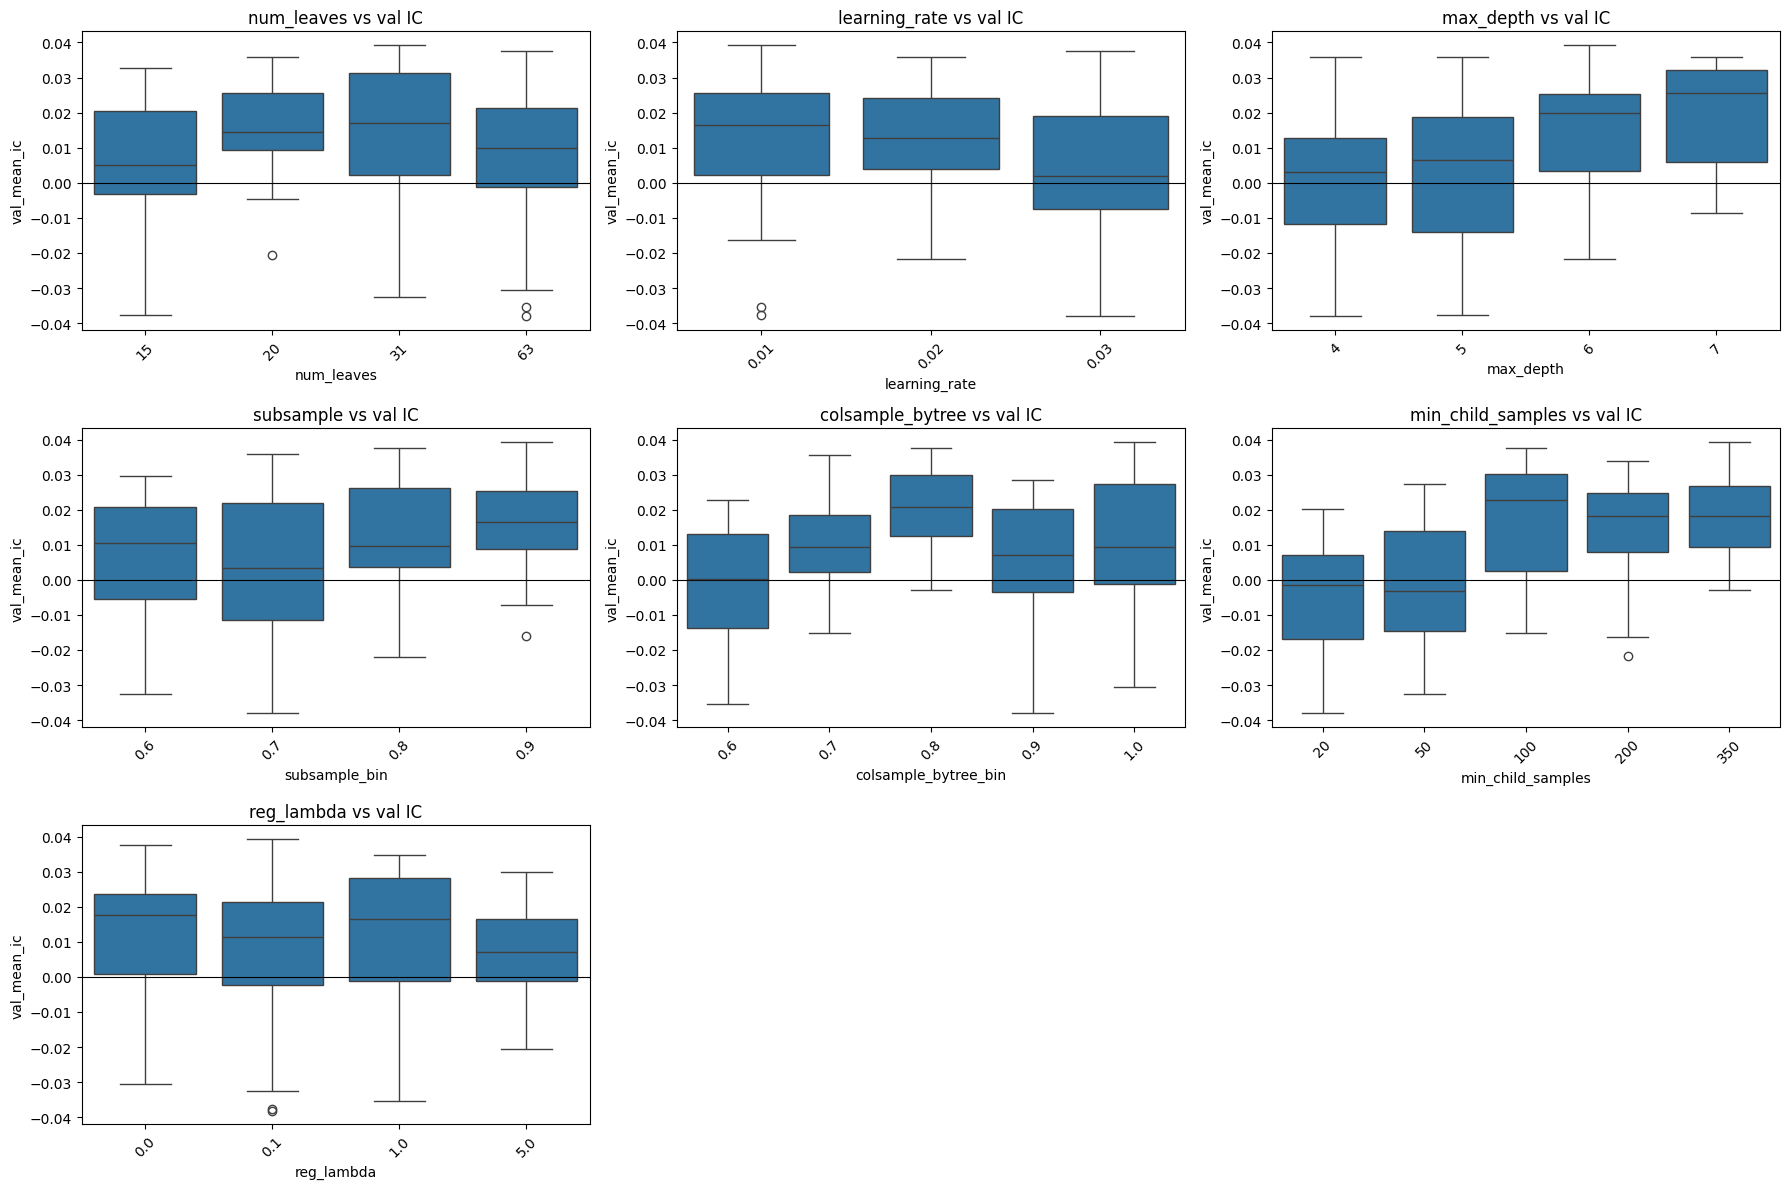

In [9]:
params_to_plot = [
    "num_leaves",
    "learning_rate",
    "max_depth",
    "subsample",
    "colsample_bytree",
    "min_child_samples",
    "reg_lambda",
]

plot_df = search_df.copy()
plot_df["subsample_bin"] = plot_df["subsample"].round(1)
plot_df["colsample_bytree_bin"] = plot_df["colsample_bytree"].round(1)
plot_map = {
    "subsample": "subsample_bin",
    "colsample_bytree": "colsample_bytree_bin",
}

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.ravel()

for i, param in enumerate(params_to_plot):
    ax = axes[i]
    xcol = plot_map.get(param, param)
    sns.boxplot(x=plot_df[xcol], y=plot_df["val_mean_ic"], ax=ax)
    ax.axhline(0.0, color="black", lw=0.8)
    ax.set_title(f"{param} vs val IC")
    ax.tick_params(axis="x", rotation=45)

for j in range(len(params_to_plot), len(axes)):
    axes[j].set_visible(False)

fig.tight_layout()
display(fig)
plt.close(fig)

## 5. Training

Frozen `BEST_PARAMS` from search — no hand overrides. Early stop on val. Holdout scored once with the IS-only model.

In [10]:
# Wired from search winners (do not hand-edit)
NUM_LEAVES = 31
LEARNING_RATE = 0.01
MAX_DEPTH = 6
SUBSAMPLE = 0.85
COLSAMPLE_BYTREE = 0.95
MIN_CHILD_SAMPLES = 350
REG_LAMBDA = 0.1

print("Final HP constants:")
print(f"  NUM_LEAVES={NUM_LEAVES}")
print(f"  LEARNING_RATE={LEARNING_RATE}")
print(f"  MAX_DEPTH={MAX_DEPTH}")
print(f"  SUBSAMPLE={SUBSAMPLE:.4f}")
print(f"  COLSAMPLE_BYTREE={COLSAMPLE_BYTREE:.4f}")
print(f"  MIN_CHILD_SAMPLES={MIN_CHILD_SAMPLES}")
print(f"  REG_LAMBDA={REG_LAMBDA}")

Final HP constants:
  NUM_LEAVES=31
  LEARNING_RATE=0.01
  MAX_DEPTH=6
  SUBSAMPLE=0.8500
  COLSAMPLE_BYTREE=0.9500
  MIN_CHILD_SAMPLES=350
  REG_LAMBDA=0.1


In [11]:
model = LGBMRegressor(
    objective="regression",
    metric="rmse",
    num_leaves=NUM_LEAVES,
    learning_rate=LEARNING_RATE,
    n_estimators=N_ESTIMATORS_CAP,  # set high; early stopping finds the real number
    max_depth=MAX_DEPTH,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE_BYTREE,
    min_child_samples=MIN_CHILD_SAMPLES,
    reg_lambda=REG_LAMBDA,
    subsample_freq=1,
    importance_type="gain",
    verbosity=-1,
    random_state=RANDOM_SEED,
)

model.fit(
    X_train,
    y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=["train", "valid"],
    callbacks=[
        early_stopping(EARLY_STOPPING_ROUNDS),
        log_evaluation(period=50),
    ],
)

model.booster_.save_model(IS_MODEL_PATH)
joblib.dump(
    {"model": model, "evals": model.evals_result_, "best_params": BEST_PARAMS},
    IS_JOBLIB_PATH,
)
print(f"Model saved. Best iteration: {model.best_iteration_}")
print(f"  txt:    {IS_MODEL_PATH}")
print(f"  joblib: {IS_JOBLIB_PATH}")

Training until validation scores don't improve for 70 rounds
[50]	train's rmse: 0.287139	valid's rmse: 0.288646
[100]	train's rmse: 0.285894	valid's rmse: 0.28869
Early stopping, best iteration is:
[67]	train's rmse: 0.286696	valid's rmse: 0.288626
Model saved. Best iteration: 67
  txt:    c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\s1_lgbm_is.txt
  joblib: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\s1_lgbm_is.joblib


In [12]:
# Score all week-start rows with IS-only model
preds = predict_scores(model, df, FEATURE_COLS)
if "feature_date" in df.columns:
    preds = preds.merge(
        df[["date", "ticker", "feature_date"]],
        on=["date", "ticker"],
        how="left",
    )
preds.to_parquet(PRED_PATH, index=False)
print(f"Saved predictions: {PRED_PATH}")
print(f"  rows={len(preds):,}  IS={preds['is_research_is'].sum():,}  "
      f"non-IS={(~preds['is_research_is']).sum():,}")

# Holdout metrics (post-IS only) — scored once, no retuning
ho_preds = preds.loc[(~preds["is_research_is"]) & (preds["date"] > is_end)].copy()
ho_sm = mean_date_ic(ho_preds)
print(
    f"Holdout IC (IS-only model): mean={ho_sm['mean_ic']:.4f}  "
    f"ICIR={ho_sm['icir']:.3f}  n_dates={ho_sm['n']}"
)
preds.head()

Saved predictions: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\01_data\data_files\s1_equities\s1_lgbm_is_predictions.parquet
  rows=85,179  IS=41,522  non-IS=43,657
Holdout IC (IS-only model): mean=0.0175  ICIR=0.087  n_dates=181


,date,ticker,fwd_ret_5,is_research_is,score,cs_rank,feature_date
0,2010-01-05,AAPL,-0.025210,False,0.514549,0.735,2010-01-04
1,2010-01-05,ABT,0.013402,False,0.513859,0.485,2010-01-04
2,2010-01-05,ADBE,-0.024298,False,0.511010,0.375,2010-01-04
3,2010-01-05,AET,-0.009411,False,0.494237,0.110,2010-01-04
4,2010-01-05,AIG,-0.013009,False,0.511286,0.405,2010-01-04


In [13]:
# Production model: IS + post-IS holdout, early-stop on same IS val window.
# Live only — do NOT use for holdout metrics.
prod_train = pd.concat(
    [
        df.loc[df["date"].isin(train_dates)],
        holdout_df,
    ],
    axis=0,
).sort_values(["date", "ticker"])

model_prod = fit_regressor(prod_train, val_df, FEATURE_COLS, BEST_PARAMS)
model_prod.booster_.save_model(PROD_MODEL_PATH)
print(
    f"Saved production model (live only): {PROD_MODEL_PATH}\n"
    f"  best_iteration={model_prod.best_iteration_}  "
    f"trained on IS-train + holdout (val unused for metrics rewrite)"
)

Saved production model (live only): c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\s1_lgbm_production.txt
  best_iteration=6  trained on IS-train + holdout (val unused for metrics rewrite)


## 6. Evaluation

Compact holdout Alphalens tear (returns + IC) under `03_models/s1_equities/model_tests/tearsheets/`, with rolling IC/ICIR shown in-notebook. IC histogram x-axis fixed to [-0.5, 0.5].


,mean_ic,icir,n_dates
segment,,,
IS train,0.210084,1.260928,358
IS val,0.034751,0.153267,63
IS train+val,0.183847,0.981225,421
OS holdout,0.017541,0.087247,181


IS train+val IC=0.1838 ICIR=0.981  |  OS holdout IC=0.0175 ICIR=0.087


,gain
smart_beta_hml_252,275.402564
beta_mkt_interact,152.519515
filing_clock_expected_until,114.826714
upside_beta_42,98.137331
val_mom_resid_126_252_10,92.000180
abnormal_volume,70.375556
smart_residual_mom_189_42,69.700430
smart_beta_mom_126,68.801336
obv_mom_soft_126_21_20,68.322815
gdelt_abnormal_attention_5_60,67.108054


Returns Analysis


,5D
Ann. alpha,0.038
beta,0.188
Mean Period Wise Return Top Quantile (bps),16.953
Mean Period Wise Return Bottom Quantile (bps),-10.479
Mean Period Wise Spread (bps),27.432


Information Analysis


,5D
IC Mean,0.018
IC Std.,0.201
Risk-Adjusted IC,0.087
t-stat(IC),NaN
p-value(IC),NaN
IC Skew,NaN
IC Kurtosis,NaN


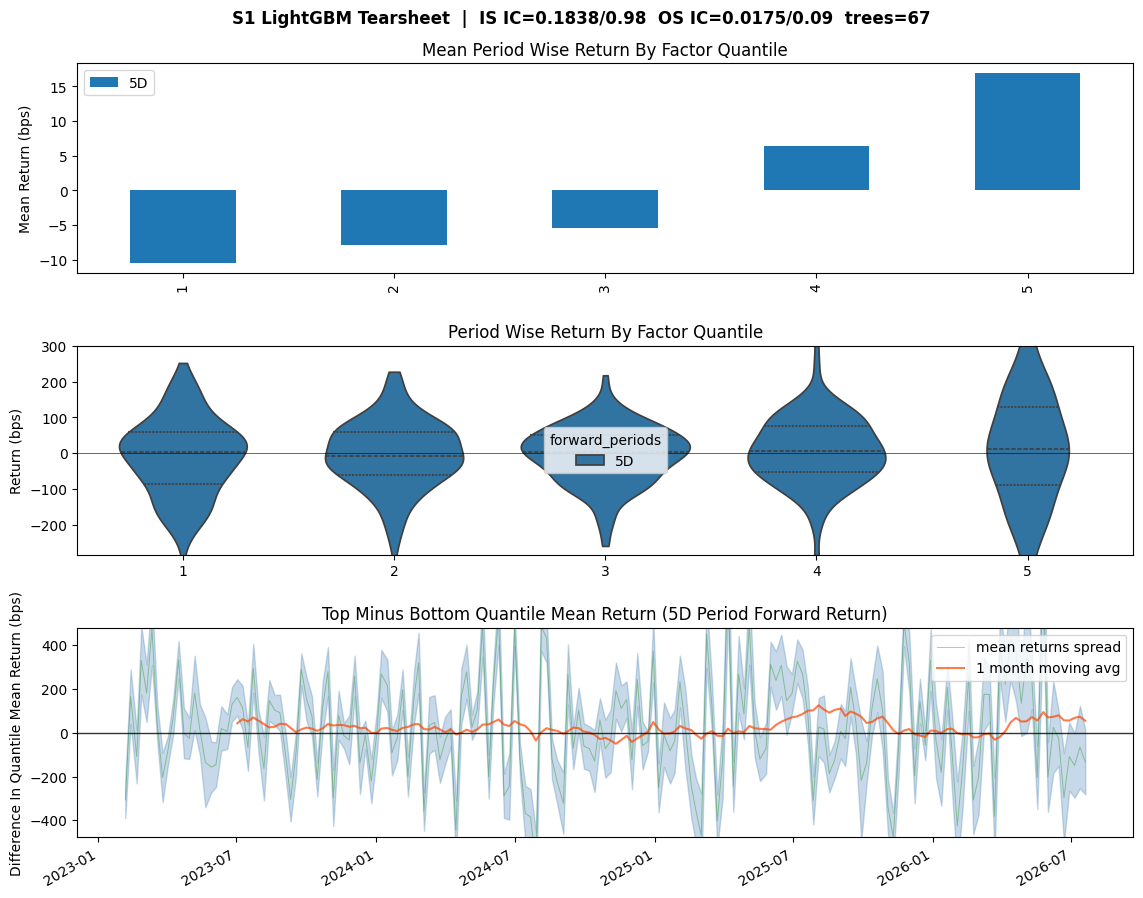

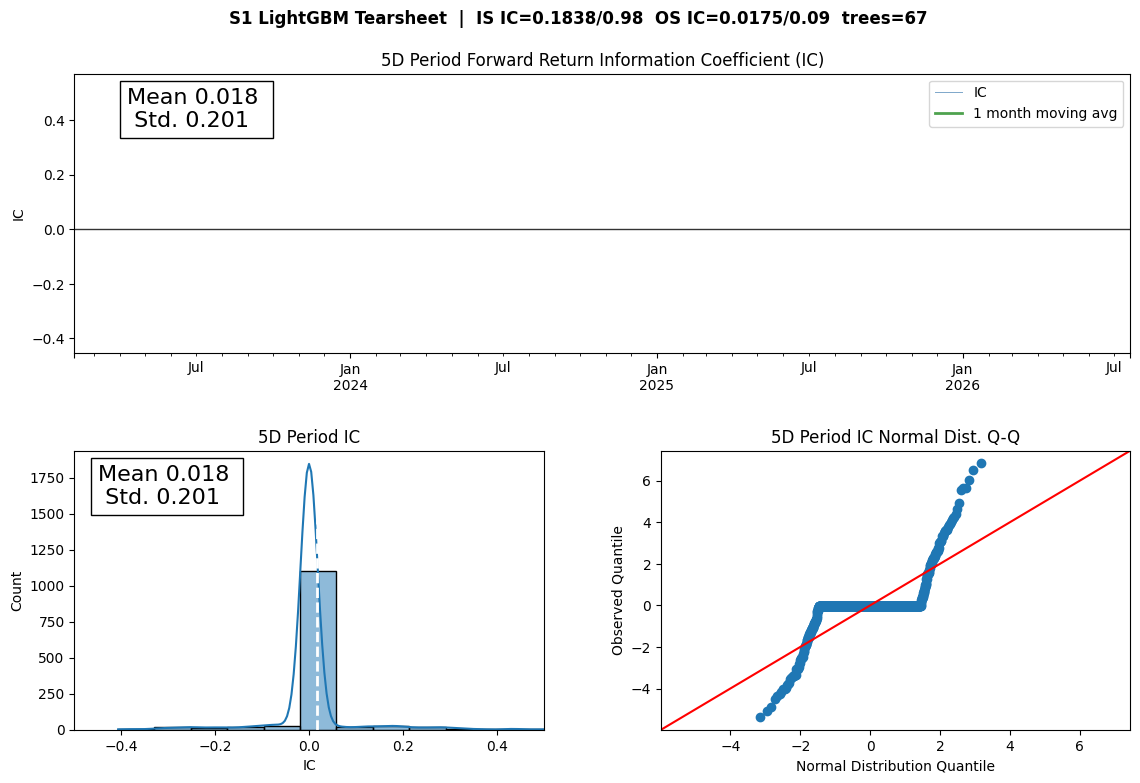

Rolling plot points: weekly_ic=181  roll_ic=169  roll_icir=169


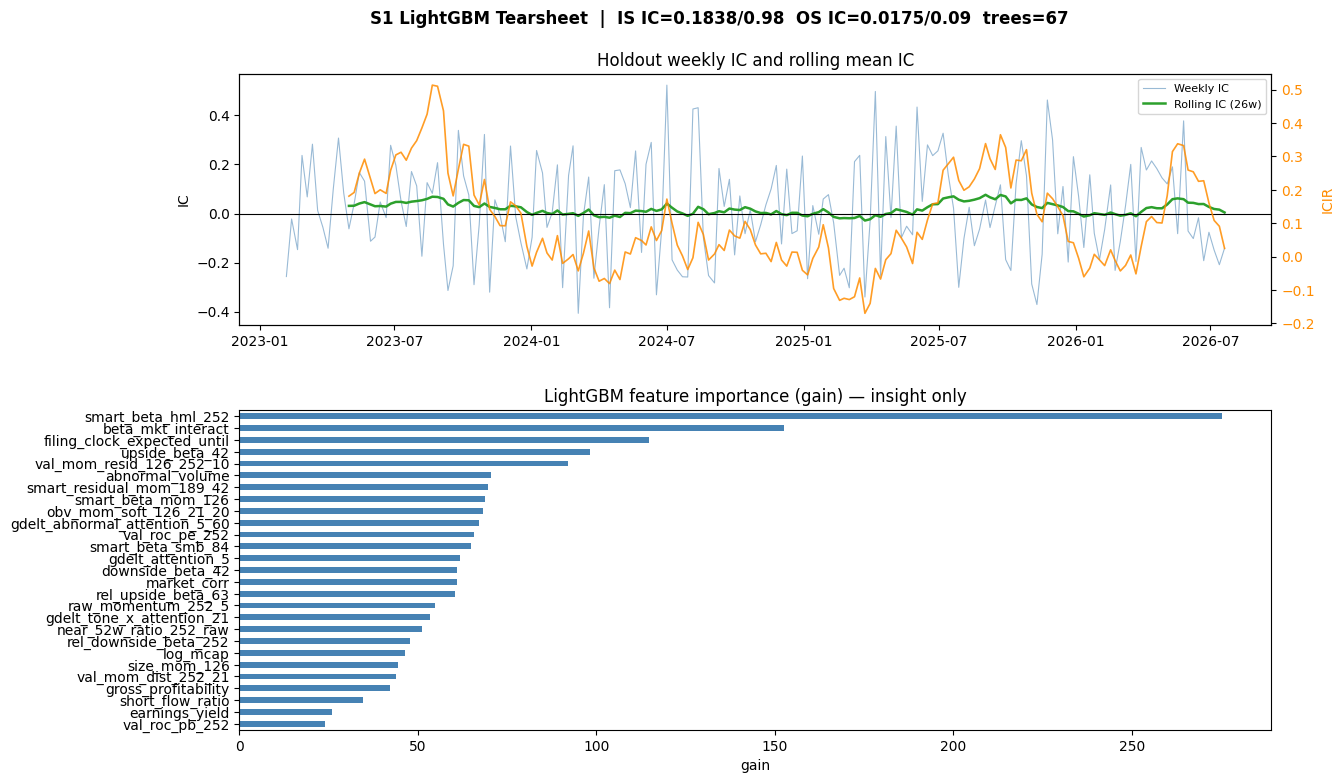

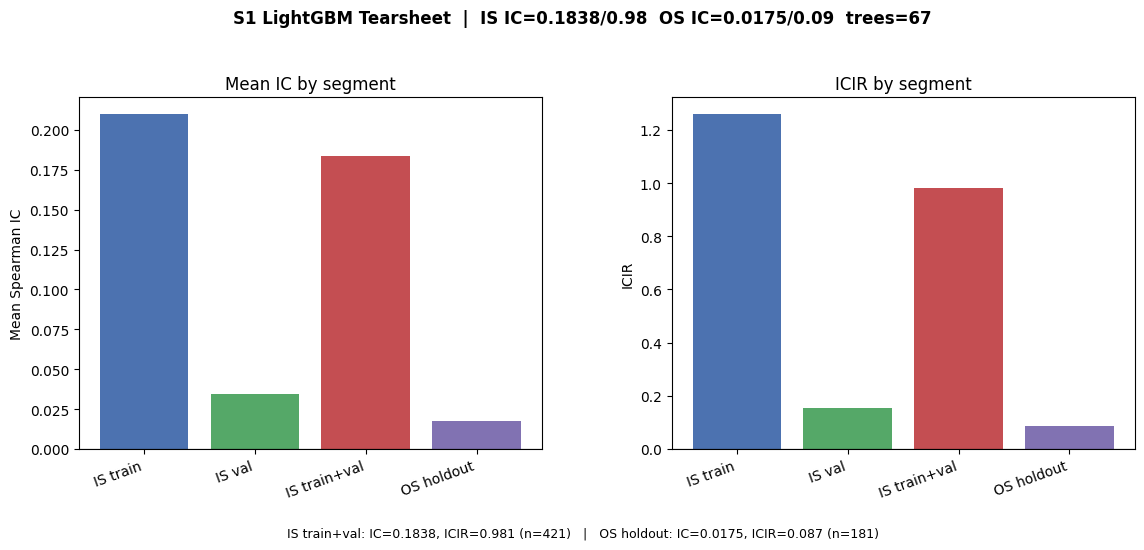

Wrote tearsheet: c:\Users\User\Desktop\ML Algorithmic Trading\Portfolio 26\trading_portfolio\03_models\s1_equities\tearsheets\s1_lgbm_gbm_training.pdf


In [14]:
from alphalens import performance as al_perf
from alphalens import plotting as al_plot
from alphalens import utils as al_utils
import matplotlib.gridspec as gridspec

# Holdout weekly IC series (tear scope)
ho_ics = date_ic_series(ho_preds).dropna().sort_index()

# IS train / val / train+val vs OS (holdout) IC & ICIR — IS-only model scores
is_train_preds = preds.loc[preds["date"].isin(train_dates)].copy()
is_val_preds = preds.loc[preds["date"].isin(val_dates)].copy()
is_tv_preds = preds.loc[preds["date"].isin(train_dates.union(val_dates))].copy()

is_train_sm = mean_date_ic(is_train_preds)
is_val_sm = mean_date_ic(is_val_preds)
is_tv_sm = mean_date_ic(is_tv_preds)
# ho_sm already computed in §5; refresh here for tear consistency
ho_sm = mean_date_ic(ho_preds)

ic_compare = pd.DataFrame(
    [
        {"segment": "IS train", "mean_ic": is_train_sm["mean_ic"], "icir": is_train_sm["icir"], "n_dates": is_train_sm["n"]},
        {"segment": "IS val", "mean_ic": is_val_sm["mean_ic"], "icir": is_val_sm["icir"], "n_dates": is_val_sm["n"]},
        {"segment": "IS train+val", "mean_ic": is_tv_sm["mean_ic"], "icir": is_tv_sm["icir"], "n_dates": is_tv_sm["n"]},
        {"segment": "OS holdout", "mean_ic": ho_sm["mean_ic"], "icir": ho_sm["icir"], "n_dates": ho_sm["n"]},
    ]
)
display(ic_compare.set_index("segment"))
print(
    f"IS train+val IC={is_tv_sm['mean_ic']:.4f} ICIR={is_tv_sm['icir']:.3f}  |  "
    f"OS holdout IC={ho_sm['mean_ic']:.4f} ICIR={ho_sm['icir']:.3f}"
)

# Rolling IC / ICIR — clip std so ICIR is defined when IC is nearly flat
_min_roll = max(8, ROLLING_IC_WEEKS // 2)
roll_ic = ho_ics.rolling(ROLLING_IC_WEEKS, min_periods=_min_roll).mean()
roll_std = ho_ics.rolling(ROLLING_IC_WEEKS, min_periods=_min_roll).std()
roll_icir = roll_ic / roll_std.clip(lower=1e-6)

importance = (
    pd.Series(model.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=False)
    .rename("gain")
)
display(importance.head(15).to_frame())

# Alphalens factor_data from S1 panel labels
factor = ho_preds.set_index(["date", "ticker"])["score"].dropna().sort_index()
fwd = (
    ho_preds.set_index(["date", "ticker"])[LABEL_COL]
    .dropna()
    .rename("5D")
    .to_frame()
)
factor.index = factor.index.set_levels(pd.to_datetime(factor.index.levels[0]), level=0)
fwd.index = fwd.index.set_levels(pd.to_datetime(fwd.index.levels[0]), level=0)
factor.index = factor.index.set_names(["date", "asset"])
fwd.index = fwd.index.set_names(["date", "asset"])

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    factor_data = al.utils.get_clean_factor(
        factor,
        fwd,
        quantiles=5,
        max_loss=0.35,
    )

long_short = True
factor_returns = al_perf.factor_returns(factor_data, long_short, False)
mean_quant_ret, _ = al_perf.mean_return_by_quantile(
    factor_data, by_group=False, demeaned=long_short, group_adjust=False
)
mean_quant_rateret = mean_quant_ret.apply(
    al_utils.rate_of_return, axis=0, base_period=mean_quant_ret.columns[0]
)
mean_quant_ret_bydate, std_quant_daily = al_perf.mean_return_by_quantile(
    factor_data, by_date=True, by_group=False, demeaned=long_short, group_adjust=False
)
mean_quant_rateret_bydate = mean_quant_ret_bydate.apply(
    al_utils.rate_of_return, axis=0, base_period=mean_quant_ret_bydate.columns[0]
)
compstd_quant_daily = std_quant_daily.apply(
    al_utils.std_conversion, axis=0, base_period=std_quant_daily.columns[0]
)
alpha_beta = al_perf.factor_alpha_beta(factor_data, factor_returns, long_short, False)
mean_ret_spread_quant, std_spread_quant = al_perf.compute_mean_returns_spread(
    mean_quant_rateret_bydate,
    factor_data["factor_quantile"].max(),
    factor_data["factor_quantile"].min(),
    std_err=compstd_quant_daily,
)
ic = al_perf.factor_information_coefficient(factor_data)

al_plot.plot_returns_table(alpha_beta, mean_quant_rateret, mean_ret_spread_quant)
al_plot.plot_information_table(ic)

TEAR_TITLE = (
    "S1 LightGBM Tearsheet  |  "
    + f"IS IC={is_tv_sm['mean_ic']:.4f}/{is_tv_sm['icir']:.2f}  "
    + f"OS IC={ho_sm['mean_ic']:.4f}/{ho_sm['icir']:.2f}  "
    + f"trees={model.best_iteration_}"
)

os.makedirs(TEARSHEET_DIR, exist_ok=True)
pdf = PdfPages(TEARSHEET_PATH)


def _save_and_show(fig):
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    pdf.savefig(fig, bbox_inches="tight")
    display(fig)
    plt.close(fig)


# --- Page 1: Returns (compact) ---
fig = plt.figure(figsize=(12, 9))
fig.suptitle(TEAR_TITLE, fontsize=12, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(
    3, 1, figure=fig, hspace=0.35, top=0.92, bottom=0.06, left=0.08, right=0.96
)
ax0 = fig.add_subplot(gs[0])
ax1 = fig.add_subplot(gs[1])
ax2 = fig.add_subplot(gs[2])
al_plot.plot_quantile_returns_bar(mean_quant_rateret, by_group=False, ax=ax0)
al_plot.plot_quantile_returns_violin(
    mean_quant_rateret_bydate, ylim_percentiles=(1, 99), ax=ax1
)
al_plot.plot_mean_quantile_returns_spread_time_series(
    mean_ret_spread_quant,
    std_err=std_spread_quant,
    bandwidth=0.5,
    ax=[ax2],
)
_save_and_show(fig)

# --- Page 2: Information / IC (compact); hist xlim [-0.5, 0.5] ---
fig = plt.figure(figsize=(12, 8))
fig.suptitle(TEAR_TITLE, fontsize=12, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(
    2,
    2,
    figure=fig,
    hspace=0.35,
    wspace=0.25,
    top=0.90,
    bottom=0.08,
    left=0.08,
    right=0.96,
)
ax_ts = fig.add_subplot(gs[0, :])
ax_hist = fig.add_subplot(gs[1, 0])
ax_qq = fig.add_subplot(gs[1, 1])
al_plot.plot_ic_ts(ic, ax=[ax_ts])
al_plot.plot_ic_hist(ic, ax=[ax_hist])
al_plot.plot_ic_qq(ic, ax=[ax_qq])
ax_hist.set_xlim(-0.5, 0.5)
ax_hist.set_title("5D Period IC")
_save_and_show(fig)

# --- Page 3: Rolling IC / ICIR + importance ---
fig = plt.figure(figsize=(12, 8))
fig.suptitle(TEAR_TITLE, fontsize=12, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(
    2,
    1,
    figure=fig,
    height_ratios=[1.1, 1.4],
    hspace=0.30,
    top=0.90,
    bottom=0.08,
    left=0.10,
    right=0.96,
)
ax_roll = fig.add_subplot(gs[0])
ax_imp = fig.add_subplot(gs[1])

ax_roll.plot(ho_ics.index, ho_ics.to_numpy(), color="steelblue", lw=0.8, alpha=0.55, label="Weekly IC")
_ric_mean = roll_ic.dropna()
ax_roll.plot(_ric_mean.index, _ric_mean.to_numpy(), color="C2", lw=1.8, label=f"Rolling IC ({ROLLING_IC_WEEKS}w)")
ax_roll.axhline(0.0, color="black", lw=0.8)
ax_roll.set_ylabel("IC")
ax_roll.set_title("Holdout weekly IC and rolling mean IC")
ax_roll.legend(loc="upper right", fontsize=8)

ax_icir = ax_roll.twinx()
_ric = roll_icir.dropna()
ax_icir.plot(_ric.index, _ric.to_numpy(), color="darkorange", lw=1.2, alpha=0.85, label="Rolling ICIR")
ax_icir.set_ylabel("ICIR", color="darkorange")
ax_icir.tick_params(axis="y", labelcolor="darkorange")
print(
    f"Rolling plot points: weekly_ic={len(ho_ics)}  "
    f"roll_ic={_ric_mean.shape[0]}  roll_icir={_ric.shape[0]}"
)

importance.iloc[::-1].plot(kind="barh", ax=ax_imp, color="steelblue")
ax_imp.set_title("LightGBM feature importance (gain) — insight only")
ax_imp.set_xlabel("gain")
_save_and_show(fig)

# --- Page 4: IS train/val vs OS holdout IC / ICIR ---
fig = plt.figure(figsize=(12, 5.5))
fig.suptitle(TEAR_TITLE, fontsize=12, fontweight="bold", y=0.98)
gs = gridspec.GridSpec(1, 2, figure=fig, wspace=0.28, top=0.82, bottom=0.18, left=0.08, right=0.96)
ax_ic = fig.add_subplot(gs[0])
ax_icir = fig.add_subplot(gs[1])

_seg = ic_compare["segment"].tolist()
_x = range(len(_seg))
_colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
ax_ic.bar(_x, ic_compare["mean_ic"].to_numpy(), color=_colors)
ax_ic.axhline(0.0, color="black", lw=0.8)
ax_ic.set_xticks(list(_x))
ax_ic.set_xticklabels(_seg, rotation=20, ha="right")
ax_ic.set_ylabel("Mean Spearman IC")
ax_ic.set_title("Mean IC by segment")

ax_icir.bar(_x, ic_compare["icir"].to_numpy(), color=_colors)
ax_icir.axhline(0.0, color="black", lw=0.8)
ax_icir.set_xticks(list(_x))
ax_icir.set_xticklabels(_seg, rotation=20, ha="right")
ax_icir.set_ylabel("ICIR")
ax_icir.set_title("ICIR by segment")

fig.text(
    0.5,
    0.02,
    (
        f"IS train+val: IC={is_tv_sm['mean_ic']:.4f}, ICIR={is_tv_sm['icir']:.3f} (n={is_tv_sm['n']})   |   "
        f"OS holdout: IC={ho_sm['mean_ic']:.4f}, ICIR={ho_sm['icir']:.3f} (n={ho_sm['n']})"
    ),
    ha="center",
    fontsize=9,
)
_save_and_show(fig)

# --- Page 5: Summary ---
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle(TEAR_TITLE, fontsize=12, fontweight="bold", y=0.98)
ax.axis("off")
summary_lines = [
    f"Model: {os.path.basename(IS_MODEL_PATH)}  (IS-only scores)",
    "",
    "IC / ICIR comparison (Spearman vs fwd_ret_5):",
    f"  IS train:      IC={is_train_sm['mean_ic']:.4f}  ICIR={is_train_sm['icir']:.3f}  n={is_train_sm['n']}",
    f"  IS val:        IC={is_val_sm['mean_ic']:.4f}  ICIR={is_val_sm['icir']:.3f}  n={is_val_sm['n']}",
    f"  IS train+val:  IC={is_tv_sm['mean_ic']:.4f}  ICIR={is_tv_sm['icir']:.3f}  n={is_tv_sm['n']}",
    f"  OS holdout:    IC={ho_sm['mean_ic']:.4f}  ICIR={ho_sm['icir']:.3f}  n={ho_sm['n']}",
    "",
    f"Best iteration:   {model.best_iteration_}",
    f"BEST_PARAMS: {BEST_PARAMS}",
]
ax.text(0.02, 0.92, "\n".join(summary_lines), va="top", family="monospace", fontsize=10)
fig.tight_layout(rect=[0, 0, 1, 0.92])
pdf.savefig(fig, bbox_inches="tight")
plt.close(fig)

pdf.close()
print(f"Wrote tearsheet: {TEARSHEET_PATH}")